In [4]:
# First, install required packages
!pip install gymnasium matplotlib numpy pandas
!pip install torch --index-url https://download.pytorch.org/whl/cpu


!pip install stable-baselines3

Looking in indexes: https://download.pytorch.org/whl/cpu


LIMIT ORDER BOOK MARKET SIMULATION SYSTEM

1. Testing Basic Order Book Functionality...
Testing Basic Order Book Functionality

Adding orders to book...

ORDER BOOK SNAPSHOT

Mid Price: $100.00
Spread: $1.00
Last Trade: $100.00
Total Trades: 0
Volume Traded: 0

------------------------------------------------------------
     Price     Quantity       Side
------------------------------------------------------------
    101.00            3        ASK
    100.50            8        ASK
------------------------------------------------------------
     99.50           10        BID
     99.00            5        BID

Testing Market Order...
  Market order executed: {'trade_id': '7d8f05f4-9221-4d9e-80bd-34ceebca57f4', 'timestamp': datetime.datetime(2025, 12, 28, 19, 22, 21, 122274), 'price': 100.5, 'quantity': 5, 'bidder': 'MARKET_TRADER', 'asker': 'TEST_3', 'aggressive_side': 'MARKET_BID'}

ORDER BOOK SNAPSHOT

Mid Price: $100.00
Spread: $1.00
Last Trade: $100.50
Total Trades: 1
Volume Tra

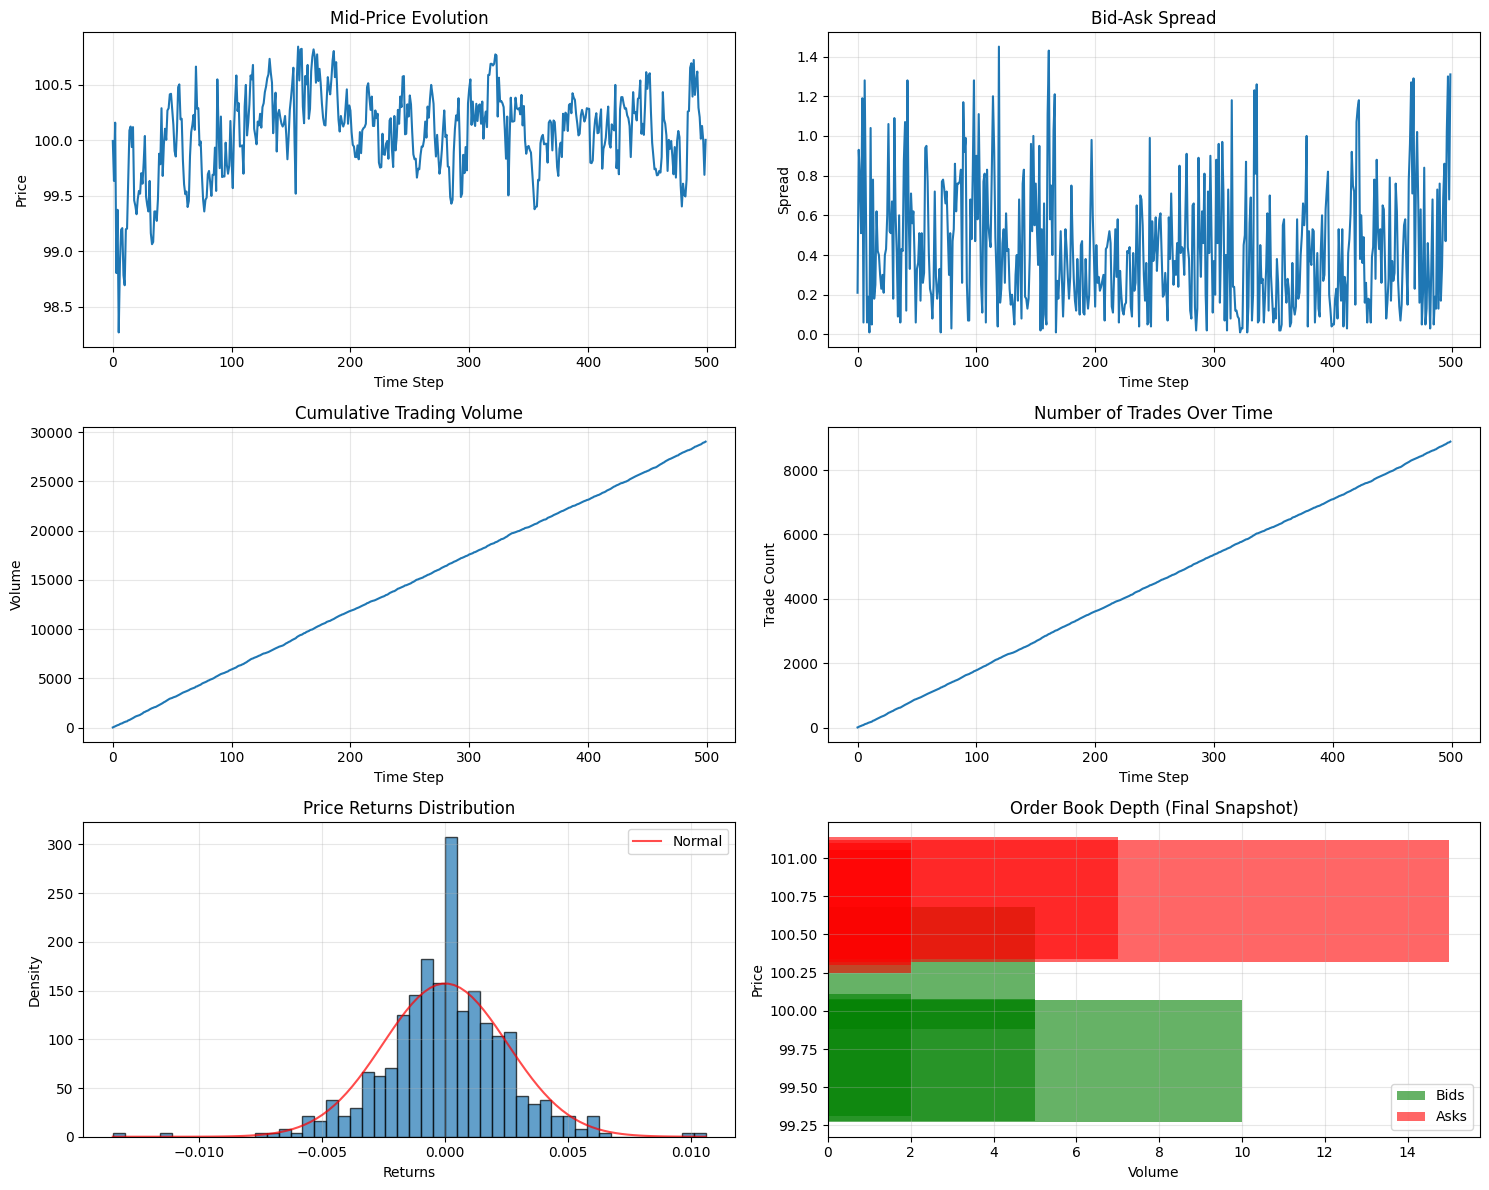


TRADER STATISTICS
Trader: MM_0
  Capital: $100000.00
  Inventory: 0
  Trades: 0
  Volume: 0
----------------------------------------
Trader: ZI_1
  Capital: $96005.87
  Inventory: 40.0
  Trades: 137
  Volume: 480
----------------------------------------
Trader: MM_2
  Capital: $100000.00
  Inventory: 0
  Trades: 0
  Volume: 0
----------------------------------------
Trader: ZI_3
  Capital: $96323.91
  Inventory: 37.0
  Trades: 84
  Volume: 343
----------------------------------------
Trader: ZI_4
  Capital: $98994.51
  Inventory: 10.0
  Trades: 149
  Volume: 566
----------------------------------------
Trader: MM_5
  Capital: $99201.08
  Inventory: 8.0
  Trades: 4
  Volume: 10
----------------------------------------
Trader: ZI_6
  Capital: $94376.95
  Inventory: 56.0
  Trades: 93
  Volume: 376
----------------------------------------
Trader: MM_7
  Capital: $100000.00
  Inventory: 0
  Trades: 0
  Volume: 0
----------------------------------------
Trader: ZI_8
  Capital: $90993.85
  I

In [5]:
"""
COMPREHENSIVE LIMIT ORDER BOOK SYSTEM WITH MULTI-AGENT TRADING ENVIRONMENT
FIXED VERSION - NO DEPENDENCY ISSUES
"""

import numpy as np
import pandas as pd
from datetime import datetime, timezone
from typing import List, Dict, Tuple, Optional, Any
from enum import Enum
import heapq
from collections import defaultdict, deque
import json
import uuid
import random
from dataclasses import dataclass, field
from abc import ABC, abstractmethod
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Try to import gymnasium, fall back to simpler implementation if not available
try:
    import gymnasium as gym
    from gymnasium import spaces
    GYMNASIUM_AVAILABLE = True
except ImportError:
    print("Gymnasium not available. Using simplified environment.")
    GYMNASIUM_AVAILABLE = False

# ============================================
# 1. ORDER BOOK CORE ENGINE (Zero-Intelligence Inspired)
# ============================================

class OrderType(Enum):
    LIMIT = "LIMIT"
    MARKET = "MARKET"
    IOC = "IOC"  # Immediate or Cancel
    FOK = "FOK"  # Fill or Kill

class OrderSide(Enum):
    BID = "BID"
    ASK = "ASK"

@dataclass
class Order:
    """Market microstructure order representation"""
    order_id: str
    timestamp: datetime
    side: OrderSide
    order_type: OrderType
    price: float
    quantity: int
    trader_id: str

    # Custom comparison for priority queue
    def __lt__(self, other):
        if self.side == OrderSide.BID:
            # Higher bids first for bids
            return self.price > other.price
        else:
            # Lower asks first for asks
            return self.price < other.price

    def __eq__(self, other):
        if not isinstance(other, Order):
            return False
        return self.order_id == other.order_id

class LimitOrderBook:
    """
    High-performance LOB implementation with price-time priority
    Based on PyLOB and Gsell (2008) microstructure research
    """

    def __init__(self, tick_size: float = 0.01, max_levels: int = 10):
        self.tick_size = tick_size
        self.max_levels = max_levels

        # Core data structures
        self.bids = []  # Max-heap for bids (highest price first)
        self.asks = []  # Min-heap for asks (lowest price first)

        # For O(1) order lookups and cancellations
        self.order_map = {}  # order_id -> (side, heap_index)
        self.price_levels = {
            OrderSide.BID: defaultdict(list),
            OrderSide.ASK: defaultdict(list)
        }

        # Market statistics
        self.trades = []
        self.order_history = []
        self.spread_history = []

        # Reference prices
        self.mid_price = 100.0
        self.last_trade_price = 100.0

        # Market state tracking
        self.order_sequence = 0
        self.volume_traded = 0
        self.total_value_traded = 0.0

    def add_order(self, order: Order) -> List[Dict]:
        """
        Process new order with price-time priority matching
        Returns list of trades executed
        """
        self.order_sequence += 1
        order.timestamp = datetime.now(timezone.utc).replace(tzinfo=None)
        self.order_history.append(order)

        trades = []

        if order.order_type == OrderType.MARKET:
            trades = self._match_market_order(order)
        elif order.order_type == OrderType.LIMIT:
            trades = self._match_limit_order(order)
        elif order.order_type == OrderType.IOC:
            trades = self._match_ioc_order(order)
        elif order.order_type == OrderType.FOK:
            trades = self._match_fok_order(order)

        # Update market statistics
        for trade in trades:
            self.volume_traded += trade['quantity']
            self.total_value_traded += trade['price'] * trade['quantity']
            self.last_trade_price = trade['price']
            self.trades.append(trade)

        # Update spread
        self._update_market_state()

        return trades

    def _match_limit_order(self, order: Order) -> List[Dict]:
        """Limit order matching with partial fills"""
        trades = []
        remaining_qty = order.quantity

        while remaining_qty > 0:
            if order.side == OrderSide.BID:
                # Check if best ask is <= bid price
                if not self.asks or self.asks[0].price > order.price:
                    break
                best_ask = self.asks[0]
            else:
                # Check if best bid is >= ask price
                if not self.bids or self.bids[0].price < order.price:
                    break
                best_bid = self.bids[0]

            # Determine match price and quantity
            match_price = best_ask.price if order.side == OrderSide.BID else best_bid.price
            match_qty = min(remaining_qty,
                          best_ask.quantity if order.side == OrderSide.BID else best_bid.quantity)

            # Execute trade
            trade = {
                'trade_id': str(uuid.uuid4()),
                'timestamp': datetime.now(timezone.utc).replace(tzinfo=None),
                'price': match_price,
                'quantity': match_qty,
                'bidder': order.trader_id if order.side == OrderSide.BID else best_bid.trader_id,
                'asker': best_ask.trader_id if order.side == OrderSide.BID else order.trader_id,
                'aggressive_side': order.side.value
            }
            trades.append(trade)

            # Update quantities
            remaining_qty -= match_qty

            if order.side == OrderSide.BID:
                best_ask.quantity -= match_qty
                if best_ask.quantity == 0:
                    heapq.heappop(self.asks)
                    self._remove_order_from_map(best_ask.order_id)
            else:
                best_bid.quantity -= match_qty
                if best_bid.quantity == 0:
                    heapq.heappop(self.bids)
                    self._remove_order_from_map(best_bid.order_id)

        # If remaining quantity, add to book
        if remaining_qty > 0:
            order.quantity = remaining_qty
            self._add_to_book(order)

        return trades

    def _match_market_order(self, order: Order) -> List[Dict]:
        """Market order matching (takes liquidity)"""
        trades = []
        remaining_qty = order.quantity

        while remaining_qty > 0:
            if order.side == OrderSide.BID:
                if not self.asks:
                    break  # No liquidity
                best_ask = self.asks[0]
            else:
                if not self.bids:
                    break
                best_bid = self.bids[0]

            match_price = best_ask.price if order.side == OrderSide.BID else best_bid.price
            match_qty = min(remaining_qty,
                          best_ask.quantity if order.side == OrderSide.BID else best_bid.quantity)

            trade = {
                'trade_id': str(uuid.uuid4()),
                'timestamp': datetime.now(timezone.utc).replace(tzinfo=None),
                'price': match_price,
                'quantity': match_qty,
                'bidder': order.trader_id if order.side == OrderSide.BID else best_bid.trader_id,
                'asker': best_ask.trader_id if order.side == OrderSide.BID else order.trader_id,
                'aggressive_side': 'MARKET_' + order.side.value
            }
            trades.append(trade)

            remaining_qty -= match_qty

            if order.side == OrderSide.BID:
                best_ask.quantity -= match_qty
                if best_ask.quantity == 0:
                    heapq.heappop(self.asks)
                    self._remove_order_from_map(best_ask.order_id)
            else:
                best_bid.quantity -= match_qty
                if best_bid.quantity == 0:
                    heapq.heappop(self.bids)
                    self._remove_order_from_map(best_bid.order_id)

        return trades

    def _match_ioc_order(self, order: Order) -> List[Dict]:
        """Immediate or Cancel order matching"""
        # Try to match like a limit order, but don't add to book
        trades = self._match_limit_order(order)
        # IOC orders don't stay in book
        return trades

    def _match_fok_order(self, order: Order) -> List[Dict]:
        """Fill or Kill order matching"""
        # Check if entire quantity can be filled
        can_fill = True
        temp_qty = order.quantity

        if order.side == OrderSide.BID:
            # Check bids against asks
            for ask in sorted(self.asks, key=lambda x: x.price):
                if ask.price > order.price:
                    can_fill = False
                    break
                temp_qty -= ask.quantity
                if temp_qty <= 0:
                    break
            if temp_qty > 0:
                can_fill = False
        else:
            # Check asks against bids
            for bid in sorted(self.bids, key=lambda x: x.price, reverse=True):
                if bid.price < order.price:
                    can_fill = False
                    break
                temp_qty -= bid.quantity
                if temp_qty <= 0:
                    break
            if temp_qty > 0:
                can_fill = False

        if can_fill:
            return self._match_limit_order(order)
        return []

    def _add_to_book(self, order: Order):
        """Add limit order to the appropriate book"""
        if order.side == OrderSide.BID:
            heapq.heappush(self.bids, order)
            heap_idx = len(self.bids) - 1
        else:
            heapq.heappush(self.asks, order)
            heap_idx = len(self.asks) - 1

        # Track in order map
        self.order_map[order.order_id] = (order.side, heap_idx)

        # Update price levels
        self.price_levels[order.side][order.price].append(order)

    def _remove_order_from_map(self, order_id: str):
        """Remove order from tracking map"""
        if order_id in self.order_map:
            del self.order_map[order_id]

    def cancel_order(self, order_id: str) -> bool:
        """Cancel existing order"""
        if order_id not in self.order_map:
            return False

        side, idx = self.order_map[order_id]

        if side == OrderSide.BID:
            if idx < len(self.bids):
                # Replace with last element and heapify
                self.bids[idx] = self.bids[-1]
                self.bids.pop()
                if idx < len(self.bids):
                    heapq._siftup(self.bids, idx)
                    heapq._siftdown(self.bids, 0, idx)
        else:
            if idx < len(self.asks):
                self.asks[idx] = self.asks[-1]
                self.asks.pop()
                if idx < len(self.asks):
                    heapq._siftup(self.asks, idx)
                    heapq._siftdown(self.asks, 0, idx)

        del self.order_map[order_id]
        self._update_market_state()
        return True

    def _update_market_state(self):
        """Update market statistics"""
        if self.bids and self.asks:
            best_bid = self.bids[0].price
            best_ask = self.asks[0].price
            self.mid_price = (best_bid + best_ask) / 2
            spread = best_ask - best_bid
            self.spread_history.append({
                'timestamp': datetime.now(timezone.utc).replace(tzinfo=None),
                'spread': spread,
                'best_bid': best_bid,
                'best_ask': best_ask
            })
        elif self.bids:
            self.mid_price = self.bids[0].price
        elif self.asks:
            self.mid_price = self.asks[0].price

    def get_market_depth(self, levels: int = 5) -> Dict:
        """Get order book depth"""
        bid_levels = defaultdict(int)
        ask_levels = defaultdict(int)

        # Get top bids
        for order in heapq.nsmallest(min(levels, len(self.bids)), self.bids):
            bid_levels[order.price] += order.quantity

        # Get top asks
        for order in heapq.nsmallest(min(levels, len(self.asks)), self.asks):
            ask_levels[order.price] += order.quantity

        best_bid = max(bid_levels.keys()) if bid_levels else None
        best_ask = min(ask_levels.keys()) if ask_levels else None

        spread = 0
        if best_bid and best_ask:
            spread = best_ask - best_bid

        return {
            'bids': dict(sorted(bid_levels.items(), reverse=True)),
            'asks': dict(sorted(ask_levels.items())),
            'mid_price': self.mid_price,
            'best_bid': best_bid,
            'best_ask': best_ask,
            'spread': spread
        }

    def get_volume_profile(self) -> Dict:
        """Calculate volume at price levels"""
        bid_volume = sum(order.quantity for order in self.bids)
        ask_volume = sum(order.quantity for order in self.asks)

        return {
            'bid_volume': bid_volume,
            'ask_volume': ask_volume,
            'imbalance': bid_volume - ask_volume,
            'total_volume': bid_volume + ask_volume
        }

    def print_order_book(self, levels: int = 5):
        """Print order book in human-readable format"""
        print("\n" + "="*60)
        print("ORDER BOOK SNAPSHOT")
        print("="*60)

        depth = self.get_market_depth(levels)

        print(f"\nMid Price: ${self.mid_price:.2f}")
        print(f"Spread: ${depth['spread']:.2f}" if depth['spread'] else "Spread: N/A")
        print(f"Last Trade: ${self.last_trade_price:.2f}")
        print(f"Total Trades: {len(self.trades)}")
        print(f"Volume Traded: {self.volume_traded}")

        print("\n" + "-"*60)
        print(f"{'Price':>10} {'Quantity':>12} {'Side':>10}")
        print("-"*60)

        # Print asks (descending)
        if depth['asks']:
            for price, qty in sorted(depth['asks'].items(), reverse=True):
                print(f"{price:>10.2f} {qty:>12} {'ASK':>10}")

        print("-"*60)

        # Print bids (descending)
        if depth['bids']:
            for price, qty in sorted(depth['bids'].items(), reverse=True):
                print(f"{price:>10.2f} {qty:>12} {'BID':>10}")

        print("="*60)

    def get_trade_history_df(self) -> pd.DataFrame:
        """Get trade history as DataFrame"""
        if not self.trades:
            return pd.DataFrame()

        return pd.DataFrame(self.trades)

# ============================================
# 2. TRADING AGENTS (Zero-Intelligence & Strategic)
# ============================================

class BaseTrader(ABC):
    """Abstract base trader class"""

    def __init__(self, trader_id: str, initial_capital: float = 100000):
        self.trader_id = trader_id
        self.capital = initial_capital
        self.positions = defaultdict(float)  # asset -> quantity
        self.trade_history = []
        self.pnl_history = []
        self.total_pnl = 0.0

    @abstractmethod
    def generate_order(self, market_state: Dict) -> Optional[Order]:
        pass

    def update_portfolio(self, trade: Dict, side: OrderSide):
        """Update trader's portfolio after trade"""
        price = trade['price']
        quantity = trade['quantity']

        if side == OrderSide.BID:
            # Buying
            cost = price * quantity
            if self.capital >= cost:  # Check if enough capital
                self.capital -= cost
                self.positions['asset'] += quantity
                self.trade_history.append(trade)
        else:
            # Selling
            if self.positions.get('asset', 0) >= quantity:  # Check if enough inventory
                self.capital += price * quantity
                self.positions['asset'] -= quantity
                self.trade_history.append(trade)

    def get_portfolio_value(self, current_price: float) -> float:
        """Get total portfolio value"""
        inventory_value = self.positions.get('asset', 0) * current_price
        return self.capital + inventory_value

    def get_stats(self) -> Dict:
        """Get trader statistics"""
        return {
            'trader_id': self.trader_id,
            'capital': self.capital,
            'inventory': self.positions.get('asset', 0),
            'num_trades': len(self.trade_history),
            'total_volume': sum(t.get('quantity', 0) for t in self.trade_history)
        }

class ZeroIntelligenceTrader(BaseTrader):
    """
    ZI Trader based on Gode & Sunder (1993)
    Random order submission with budget constraint
    """

    def __init__(self, trader_id: str, intensity: float = 0.5,
                 order_size_range: Tuple[int, int] = (1, 10),
                 price_range: Tuple[float, float] = (99, 101)):
        super().__init__(trader_id)
        self.intensity = intensity  # Order submission probability
        self.order_size_range = order_size_range
        self.price_range = price_range

    def generate_order(self, market_state: Dict) -> Optional[Order]:
        """Generate random order with probability = intensity"""
        if random.random() > self.intensity:
            return None

        # Randomly choose side
        side = random.choice([OrderSide.BID, OrderSide.ASK])

        # Random price within range
        price = round(random.uniform(*self.price_range), 2)

        # Random quantity
        quantity = random.randint(*self.order_size_range)

        # Random order type (mostly limit orders)
        order_type = random.choices(
            [OrderType.LIMIT, OrderType.MARKET, OrderType.IOC],
            weights=[0.7, 0.2, 0.1]
        )[0]

        return Order(
            order_id=str(uuid.uuid4()),
            timestamp=datetime.now(timezone.utc).replace(tzinfo=None),
            side=side,
            order_type=order_type,
            price=price,
            quantity=quantity,
            trader_id=self.trader_id
        )

class MarketMaker(BaseTrader):
    """
    Strategic market maker providing liquidity
    Based on Avellaneda-Stoikov model
    """

    def __init__(self, trader_id: str, inventory_target: float = 0,
                 risk_aversion: float = 0.1, spread_multiplier: float = 1.5):
        super().__init__(trader_id)
        self.inventory_target = inventory_target
        self.risk_aversion = risk_aversion
        self.spread_multiplier = spread_multiplier
        self.quote_size = 5

    def generate_order(self, market_state: Dict) -> List[Order]:
        """Generate bid and ask quotes"""
        orders = []

        mid_price = market_state.get('mid_price', 100)
        best_bid = market_state.get('best_bid', mid_price * 0.99)
        best_ask = market_state.get('best_ask', mid_price * 1.01)

        # Calculate reservation price (Avellaneda-Stoikov)
        inventory = self.positions.get('asset', 0)
        gamma = self.risk_aversion
        sigma = 0.02  # volatility estimate
        T = 1.0  # time horizon

        reservation_price = mid_price - gamma * sigma**2 * inventory * T

        # Calculate optimal spreads
        bid_spread = self.spread_multiplier * sigma * np.sqrt(T)
        ask_spread = self.spread_multiplier * sigma * np.sqrt(T)

        # Adjust for inventory
        if inventory > self.inventory_target:
            # Want to reduce inventory -> lower ask price
            ask_spread *= 0.8
            bid_spread *= 1.2
        elif inventory < self.inventory_target:
            # Want to increase inventory -> higher bid price
            bid_spread *= 0.8
            ask_spread *= 1.2

        # Generate quotes
        bid_price = round(reservation_price - bid_spread, 2)
        ask_price = round(reservation_price + ask_spread, 2)

        # Ensure bid < ask
        if bid_price >= ask_price:
            bid_price = ask_price - 0.01

        # Ensure within reasonable bounds
        bid_price = max(bid_price, mid_price * 0.95)
        ask_price = min(ask_price, mid_price * 1.05)

        # Bid order
        orders.append(Order(
            order_id=str(uuid.uuid4()),
            timestamp=datetime.now(timezone.utc).replace(tzinfo=None),
            side=OrderSide.BID,
            order_type=OrderType.LIMIT,
            price=bid_price,
            quantity=self.quote_size,
            trader_id=self.trader_id
        ))

        # Ask order
        orders.append(Order(
            order_id=str(uuid.uuid4()),
            timestamp=datetime.now(timezone.utc).replace(tzinfo=None),
            side=OrderSide.ASK,
            order_type=OrderType.LIMIT,
            price=ask_price,
            quantity=self.quote_size,
            trader_id=self.trader_id
        ))

        return orders

class MomentumTrader(BaseTrader):
    """Trend-following trader"""

    def __init__(self, trader_id: str, lookback_period: int = 10):
        super().__init__(trader_id)
        self.lookback_period = lookback_period
        self.price_history = deque(maxlen=lookback_period)

    def generate_order(self, market_state: Dict) -> Optional[Order]:
        current_price = market_state.get('mid_price', 100)
        self.price_history.append(current_price)

        if len(self.price_history) < self.lookback_period:
            return None

        # Calculate momentum
        returns = np.diff(list(self.price_history))
        momentum = np.mean(returns[-5:]) if len(returns) >= 5 else 0

        if abs(momentum) < 0.001:
            return None

        # Determine trade direction based on momentum
        if momentum > 0:
            side = OrderSide.BID  # Buy in uptrend
            price = market_state.get('best_ask', current_price) * 1.001  # Pay up slightly
        else:
            side = OrderSide.ASK  # Sell in downtrend
            price = market_state.get('best_bid', current_price) * 0.999  # Discount slightly

        quantity = random.randint(1, 5)

        return Order(
            order_id=str(uuid.uuid4()),
            timestamp=datetime.now(timezone.utc).replace(tzinfo=None),
            side=side,
            order_type=OrderType.LIMIT,
            price=round(price, 2),
            quantity=quantity,
            trader_id=self.trader_id
        )

# ============================================
# 3. MARKET SIMULATION ENVIRONMENT
# ============================================

class MarketSimulator:
    """Complete market simulation orchestrator"""

    def __init__(self, num_traders: int = 50, max_steps: int = 1000):
        self.order_book = LimitOrderBook()
        self.max_steps = max_steps

        # Initialize traders
        self.traders = self._initialize_traders(num_traders)

        # Metrics collection
        self.metrics = {
            'prices': [],
            'spreads': [],
            'volumes': [],
            'trades': [],
            'order_book_snapshots': []
        }

        # Simulation state
        self.current_step = 0

    def _initialize_traders(self, num_traders: int) -> List[BaseTrader]:
        """Initialize heterogeneous traders"""
        traders = []

        for i in range(num_traders):
            # Weight traders by type
            trader_type = random.choices(
                [ZeroIntelligenceTrader, MarketMaker, MomentumTrader],
                weights=[0.6, 0.3, 0.1]
            )[0]

            if trader_type == ZeroIntelligenceTrader:
                trader = ZeroIntelligenceTrader(
                    trader_id=f"ZI_{i}",
                    intensity=random.uniform(0.3, 0.8),
                    order_size_range=(1, random.randint(5, 20)),
                    price_range=(98, 102)
                )
            elif trader_type == MarketMaker:
                trader = MarketMaker(
                    trader_id=f"MM_{i}",
                    inventory_target=random.uniform(-50, 50),
                    risk_aversion=random.uniform(0.05, 0.2),
                    spread_multiplier=random.uniform(1.0, 2.0)
                )
            else:
                trader = MomentumTrader(
                    trader_id=f"MOM_{i}",
                    lookback_period=random.randint(5, 20)
                )

            traders.append(trader)

        return traders

    def _initialize_book(self):
        """Initialize order book with some orders"""
        for _ in range(20):
            side = random.choice([OrderSide.BID, OrderSide.ASK])
            price = 100 + random.uniform(-2, 2)
            order = Order(
                order_id=str(uuid.uuid4()),
                timestamp=datetime.now(timezone.utc).replace(tzinfo=None),
                side=side,
                order_type=OrderType.LIMIT,
                price=round(price, 2),
                quantity=random.randint(1, 10),
                trader_id=f"INIT_{_}"
            )
            self.order_book.add_order(order)

    def run_simulation(self, verbose: bool = False):
        """Run complete market simulation"""
        print("="*60)
        print("STARTING MARKET SIMULATION")
        print("="*60)

        # Reset simulation
        self.order_book = LimitOrderBook()
        self.current_step = 0
        self.metrics = {k: [] for k in self.metrics.keys()}

        # Initialize order book
        self._initialize_book()

        # Main simulation loop
        for step in range(self.max_steps):
            self.current_step = step

            # Get current market state
            market_state = self.order_book.get_market_depth()

            # Collect metrics
            self._collect_metrics(market_state)

            # Each trader generates and submits orders
            for trader in self.traders:
                orders = trader.generate_order(market_state)
                if orders:
                    if isinstance(orders, list):
                        for order in orders:
                            trades = self.order_book.add_order(order)
                            for trade in trades:
                                # Update trader portfolio if involved
                                if trade['bidder'] == trader.trader_id:
                                    trader.update_portfolio(trade, OrderSide.BID)
                                elif trade['asker'] == trader.trader_id:
                                    trader.update_portfolio(trade, OrderSide.ASK)
                    else:
                        trades = self.order_book.add_order(orders)
                        if trades:
                            trader.update_portfolio(trades[0], orders.side)

            # Occasionally print progress
            if verbose and step % 100 == 0:
                print(f"Step {step}/{self.max_steps}: "
                      f"Price=${self.order_book.mid_price:.2f}, "
                      f"Trades={len(self.order_book.trades)}, "
                      f"Volume={self.order_book.volume_traded}")

        print("\n" + "="*60)
        print("SIMULATION COMPLETED")
        print("="*60)
        print(f"Total steps: {self.max_steps}")
        print(f"Total trades: {len(self.order_book.trades)}")
        print(f"Total volume: {self.order_book.volume_traded}")
        print(f"Average spread: ${np.mean(self.metrics['spreads']):.4f}")
        print(f"Final price: ${self.order_book.mid_price:.2f}")

        return self.metrics

    def _collect_metrics(self, market_state: Dict):
        """Collect simulation metrics"""
        self.metrics['prices'].append(market_state.get('mid_price', 100))
        self.metrics['spreads'].append(market_state.get('spread', 0))
        self.metrics['volumes'].append(self.order_book.volume_traded)
        self.metrics['trades'].append(len(self.order_book.trades))

        # Take occasional order book snapshots
        if self.current_step % 50 == 0:
            self.metrics['order_book_snapshots'].append({
                'step': self.current_step,
                'order_book': market_state.copy()
            })

    def visualize_results(self):
        """Visualize simulation results"""
        fig, axes = plt.subplots(3, 2, figsize=(15, 12))

        # Price evolution
        axes[0, 0].plot(self.metrics['prices'])
        axes[0, 0].set_title('Mid-Price Evolution')
        axes[0, 0].set_xlabel('Time Step')
        axes[0, 0].set_ylabel('Price')
        axes[0, 0].grid(True, alpha=0.3)

        # Spread dynamics
        axes[0, 1].plot(self.metrics['spreads'])
        axes[0, 1].set_title('Bid-Ask Spread')
        axes[0, 1].set_xlabel('Time Step')
        axes[0, 1].set_ylabel('Spread')
        axes[0, 1].grid(True, alpha=0.3)

        # Trading volume
        axes[1, 0].plot(self.metrics['volumes'])
        axes[1, 0].set_title('Cumulative Trading Volume')
        axes[1, 0].set_xlabel('Time Step')
        axes[1, 0].set_ylabel('Volume')
        axes[1, 0].grid(True, alpha=0.3)

        # Trade count over time
        axes[1, 1].plot(self.metrics['trades'])
        axes[1, 1].set_title('Number of Trades Over Time')
        axes[1, 1].set_xlabel('Time Step')
        axes[1, 1].set_ylabel('Trade Count')
        axes[1, 1].grid(True, alpha=0.3)

        # Price return distribution
        if len(self.metrics['prices']) > 1:
            prices = np.array(self.metrics['prices'])
            returns = np.diff(prices) / prices[:-1]

            axes[2, 0].hist(returns, bins=50, alpha=0.7, edgecolor='black', density=True)
            axes[2, 0].set_title('Price Returns Distribution')
            axes[2, 0].set_xlabel('Returns')
            axes[2, 0].set_ylabel('Density')
            axes[2, 0].grid(True, alpha=0.3)

            # Add normal distribution for comparison
            x = np.linspace(returns.min(), returns.max(), 100)
            normal_pdf = (1/(np.std(returns)*np.sqrt(2*np.pi))) * np.exp(-0.5*((x-np.mean(returns))/np.std(returns))**2)
            axes[2, 0].plot(x, normal_pdf, 'r-', alpha=0.7, label='Normal')
            axes[2, 0].legend()

        # Order book snapshot visualization
        if self.metrics['order_book_snapshots']:
            latest_snapshot = self.metrics['order_book_snapshots'][-1]['order_book']

            if latest_snapshot.get('bids') and latest_snapshot.get('asks'):
                # Prepare data for order book visualization
                bid_prices = list(latest_snapshot['bids'].keys())
                bid_volumes = list(latest_snapshot['bids'].values())
                ask_prices = list(latest_snapshot['asks'].keys())
                ask_volumes = list(latest_snapshot['asks'].values())

                axes[2, 1].barh(bid_prices, bid_volumes, color='green', alpha=0.6, label='Bids')
                axes[2, 1].barh(ask_prices, ask_volumes, color='red', alpha=0.6, label='Asks')
                axes[2, 1].set_title('Order Book Depth (Final Snapshot)')
                axes[2, 1].set_xlabel('Volume')
                axes[2, 1].set_ylabel('Price')
                axes[2, 1].legend()
                axes[2, 1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig('market_simulation_results.png', dpi=150, bbox_inches='tight')
        plt.show()

    def print_trader_stats(self):
        """Print statistics for all traders"""
        print("\n" + "="*60)
        print("TRADER STATISTICS")
        print("="*60)

        for trader in self.traders[:10]:  # Print first 10 traders
            stats = trader.get_stats()
            print(f"Trader: {stats['trader_id']}")
            print(f"  Capital: ${stats['capital']:.2f}")
            print(f"  Inventory: {stats['inventory']}")
            print(f"  Trades: {stats['num_trades']}")
            print(f"  Volume: {stats['total_volume']}")
            print("-"*40)

# ============================================
# 4. DEMONSTRATION AND TESTING
# ============================================

def test_order_book_basic():
    """Test basic order book functionality"""
    print("Testing Basic Order Book Functionality")
    print("="*50)

    lob = LimitOrderBook()

    # Add some test orders
    orders = [
        Order(str(uuid.uuid4()), datetime.now(timezone.utc).replace(tzinfo=None),
              OrderSide.BID, OrderType.LIMIT, 99.5, 10, "TEST_1"),
        Order(str(uuid.uuid4()), datetime.now(timezone.utc).replace(tzinfo=None),
              OrderSide.BID, OrderType.LIMIT, 99.0, 5, "TEST_2"),
        Order(str(uuid.uuid4()), datetime.now(timezone.utc).replace(tzinfo=None),
              OrderSide.ASK, OrderType.LIMIT, 100.5, 8, "TEST_3"),
        Order(str(uuid.uuid4()), datetime.now(timezone.utc).replace(tzinfo=None),
              OrderSide.ASK, OrderType.LIMIT, 101.0, 3, "TEST_4"),
    ]

    print("\nAdding orders to book...")
    for order in orders:
        trades = lob.add_order(order)
        if trades:
            print(f"  Trade executed: {trades[0]}")

    lob.print_order_book()

    # Test market order
    print("\nTesting Market Order...")
    market_order = Order(
        str(uuid.uuid4()),
        datetime.now(timezone.utc).replace(tzinfo=None),
        OrderSide.BID,
        OrderType.MARKET,
        0,  # Price not needed for market orders
        5,
        "MARKET_TRADER"
    )

    trades = lob.add_order(market_order)
    if trades:
        print(f"  Market order executed: {trades[0]}")

    lob.print_order_book()

    # Test cancel order
    if lob.order_map:
        order_id_to_cancel = list(lob.order_map.keys())[0]
        print(f"\nCancelling order: {order_id_to_cancel}")
        if lob.cancel_order(order_id_to_cancel):
            print("  Order cancelled successfully")

    lob.print_order_book()

    return lob

def run_comprehensive_simulation():
    """Run comprehensive market simulation"""
    print("\n" + "="*60)
    print("RUNNING COMPREHENSIVE MARKET SIMULATION")
    print("="*60)

    # Create and run simulator
    simulator = MarketSimulator(num_traders=30, max_steps=500)
    metrics = simulator.run_simulation(verbose=True)

    # Visualize results
    simulator.visualize_results()

    # Print trader statistics
    simulator.print_trader_stats()

    # Print final order book
    print("\n" + "="*60)
    print("FINAL ORDER BOOK STATE")
    print("="*60)
    simulator.order_book.print_order_book()

    return simulator

def analyze_market_quality(simulator: MarketSimulator):
    """Analyze market quality metrics"""
    print("\n" + "="*60)
    print("MARKET QUALITY ANALYSIS")
    print("="*60)

    metrics = simulator.metrics

    if len(metrics['prices']) < 2:
        print("Not enough data for analysis")
        return

    # Calculate basic statistics
    prices = np.array(metrics['prices'])
    spreads = np.array(metrics['spreads'])

    print(f"Price Statistics:")
    print(f"  Initial Price: ${prices[0]:.2f}")
    print(f"  Final Price: ${prices[-1]:.2f}")
    print(f"  Price Change: ${prices[-1] - prices[0]:.2f} ({((prices[-1]/prices[0])-1)*100:.2f}%)")
    print(f"  Average Price: ${np.mean(prices):.2f}")
    print(f"  Price Volatility: {np.std(prices):.4f}")

    print(f"\nSpread Statistics:")
    print(f"  Average Spread: ${np.mean(spreads):.4f}")
    print(f"  Max Spread: ${np.max(spreads):.4f}")
    print(f"  Min Spread: ${np.min(spreads):.4f}")

    # Calculate returns statistics
    returns = np.diff(prices) / prices[:-1]

    print(f"\nReturn Statistics:")
    print(f"  Average Return: {np.mean(returns)*100:.4f}%")
    print(f"  Return Volatility: {np.std(returns)*100:.4f}%")
    print(f"  Return Skewness: {pd.Series(returns).skew():.4f}")
    print(f"  Return Kurtosis: {pd.Series(returns).kurtosis():.4f}")

    # Calculate trading statistics
    print(f"\nTrading Statistics:")
    print(f"  Total Trades: {len(simulator.order_book.trades)}")
    print(f"  Total Volume: {simulator.order_book.volume_traded}")
    print(f"  Average Trade Size: {simulator.order_book.volume_traded / max(1, len(simulator.order_book.trades)):.2f}")

    # Volume analysis
    if simulator.order_book.trades:
        trade_sizes = [t['quantity'] for t in simulator.order_book.trades]
        print(f"  Max Trade Size: {max(trade_sizes)}")
        print(f"  Min Trade Size: {min(trade_sizes)}")
        print(f"  Median Trade Size: {np.median(trade_sizes)}")

# ============================================
# 5. MAIN EXECUTION
# ============================================

if __name__ == "__main__":
    print("="*60)
    print("LIMIT ORDER BOOK MARKET SIMULATION SYSTEM")
    print("="*60)

    print("\n1. Testing Basic Order Book Functionality...")
    test_lob = test_order_book_basic()

    print("\n2. Running Comprehensive Market Simulation...")
    simulator = run_comprehensive_simulation()

    print("\n3. Analyzing Market Quality...")
    analyze_market_quality(simulator)

    print("\n" + "="*60)
    print("SIMULATION COMPLETE")
    print("="*60)

    # Export data if needed
    print("\nData available for export:")
    print("  - Order book: simulator.order_book")
    print("  - Metrics: simulator.metrics")
    print("  - Traders: simulator.traders")

    # Example: Get trade history as DataFrame
    if simulator.order_book.trades:
        trade_df = simulator.order_book.get_trade_history_df()
        print(f"\nTrade DataFrame shape: {trade_df.shape}")